# Member 3 - Support Vector Regression (SVR)
## Medical Insurance Charges Prediction

### Objective
The objective of this model is to predict medical insurance charges using Support Vector Regression and identify a suitable combination of hyperparameters through tuning.

### Model Suitability
SVR is suitable for predicting the continuous target variable `charges`. Unlike simple linear regression, SVR can model both linear and nonlinear relationships by using different kernel functions.

This is useful for medical insurance data because relationships between factors such as age, BMI, smoking status, and insurance charges may not always be purely linear.

SVR performance is influenced by hyperparameters such as `kernel`, `C`, `epsilon`, and `gamma`, which are tuned using cross-validation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
candidate_roots = [
    Path("."),
    Path("..")
]

project_root = None

for root in candidate_roots:

    train_file = (
        root
        / "data"
        / "processed"
        / "insurance_train_processed.csv"
    )

    test_file = (
        root
        / "data"
        / "processed"
        / "insurance_test_processed.csv"
    )

    if train_file.exists() and test_file.exists():
        project_root = root
        break


if project_root is None:
    raise FileNotFoundError(
        "Processed train/test CSV files were not found. "
        "Check the data/processed folder."
    )


TRAIN_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_train_processed.csv"
)

TEST_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_test_processed.csv"
)

RESULT_PATH = (
    project_root
    / "results"
    / "model_results"
)

FIGURE_PATH = (
    project_root
    / "results"
    / "model_visualizations"
)


RESULT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)


print("Project root :", project_root)
print("Train file   :", TRAIN_PATH)
print("Test file    :", TEST_PATH)

Project root : ..
Train file   : ..\data\processed\insurance_train_processed.csv
Test file    : ..\data\processed\insurance_test_processed.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)


print("\nTraining Data:")
display(train_df.head())


print("\nTesting Data:")
display(test_df.head())


print(
    "\nTraining Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Testing Missing Values:",
    test_df.isnull().sum().sum()
)


if "charges" not in train_df.columns:
    raise ValueError(
        "'charges' target column is missing from training data."
    )

if "charges" not in test_df.columns:
    raise ValueError(
        "'charges' target column is missing from testing data."
    )

Training Dataset Shape: (1069, 8)
Testing Dataset Shape : (268, 8)

Training Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-1.238193,-1.157680,-1.002462,0,-0.907908,1,2396.09590
1,0,-1.282622,-1.300619,-0.796635,0,0.766904,1,3279.86855
2,0,1.432285,0.914926,1.166632,0,0.766904,0,33471.97189
3,0,2.705024,1.701087,1.824110,1,-0.907908,1,13405.39030
4,0,0.082968,0.557580,-0.654140,0,0.766904,0,9715.84100



Testing Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-0.199877,0.700518,-1.334950,0,-0.907908,1,8688.85885
1,0,-0.894330,-0.728865,-0.820801,0,2.441716,0,5708.86700
2,0,1.248171,0.843457,0.976639,0,1.604310,0,11436.73815
3,1,-0.271365,-0.585927,0.644150,0,1.604310,1,38746.35510
4,0,-0.032718,-0.585927,1.310794,1,0.766904,1,4463.20510



Training Missing Values: 0
Testing Missing Values: 0


In [4]:
X_train = train_df.drop(
    columns=["charges"]
)

y_train = train_df["charges"]


X_test = test_df.drop(
    columns=["charges"]
)

y_test = test_df["charges"]


if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing feature columns do not match."
    )


print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)


print("\nFeatures Used:")

for feature in X_train.columns:
    print("-", feature)


print("\nTarget Statistics:")
display(y_train.describe())

X_train Shape: (1069, 7)
y_train Shape: (1069,)
X_test Shape : (268, 7)
y_test Shape : (268,)

Features Used:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- region_southeast
- children
- sex_male

Target Statistics:


count     1069.000000
mean     13030.203369
std      11706.530971
min       1121.873900
25%       4747.052900
50%       9290.139500
75%      16450.894700
max      62592.873090
Name: charges, dtype: float64

In [5]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )


    print(f"\n{model_name}")
    print("-" * 50)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Evaluation, Validation and Implementation

### Evaluation Metrics
The model is evaluated using:

- **MAE:** Measures the average absolute difference between actual and predicted charges. Lower values indicate better performance.
- **RMSE:** Gives a larger penalty to large prediction errors. Lower values indicate better performance.
- **R²:** Measures how much variation in insurance charges is explained by the model. Higher values generally indicate better performance.

### Validation and Hyperparameter Tuning
Five-fold cross-validation is used during GridSearchCV to evaluate different SVR configurations.

The following hyperparameters are tuned:

- **kernel:** Determines the type of relationship learned by SVR.
- **C:** Controls the penalty for prediction errors.
- **epsilon:** Defines the error tolerance around the regression function.
- **gamma:** Controls the influence of individual training observations for kernels such as RBF.

### Implementation
Scikit-learn `SVR` is used for model development and `GridSearchCV` is used for hyperparameter tuning. A default SVR model is first evaluated as a baseline and then compared with the tuned SVR model.

In [6]:
svr_baseline = SVR()


svr_baseline.fit(
    X_train,
    y_train
)


baseline_predictions = (
    svr_baseline.predict(
        X_test
    )
)


baseline_result = evaluate_model(
    "SVR - Baseline",
    y_test,
    baseline_predictions
)


SVR - Baseline
--------------------------------------------------
MAE  : 9251.1522
RMSE : 14424.3944
R²   : -0.1323


In [7]:
param_grid = {
    "kernel": [
        "linear",
        "rbf"
    ],

    "C": [
        1,
        10,
        100,
        1000
    ],

    "epsilon": [
        0.1,
        0.5,
        1.0
    ],

    "gamma": [
        "scale",
        "auto"
    ]
}


svr_model = SVR()


grid_search = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)


print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best Cross-Validation RMSE:",
    -grid_search.best_score_
)

Best Parameters: {'C': 1000, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation RMSE: 7380.189480744858


In [8]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)


tuning_results = pd.DataFrame({
    "Kernel":
        cv_results["param_kernel"],

    "C":
        cv_results["param_C"].astype(float),

    "Epsilon":
        cv_results["param_epsilon"].astype(float),

    "Gamma":
        cv_results["param_gamma"],

    "Mean_Train_RMSE":
        -cv_results["mean_train_score"],

    "Mean_CV_RMSE":
        -cv_results["mean_test_score"],

    "CV_RMSE_STD":
        cv_results["std_test_score"]
})


tuning_results = (
    tuning_results
    .sort_values(
        "Mean_CV_RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Top 10 SVR Configurations:"
)

display(
    tuning_results.head(10)
)

Top 10 SVR Configurations:


,Kernel,C,Epsilon,Gamma,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,linear,1000.0,0.1,scale,7393.123593,7380.189481,613.693412
1,linear,1000.0,0.1,auto,7393.123593,7380.189481,613.693412
2,linear,1000.0,0.5,scale,7393.175921,7380.237623,613.692205
3,linear,1000.0,0.5,auto,7393.175921,7380.237623,613.692205
4,linear,1000.0,1.0,auto,7393.292287,7380.350445,613.570111
5,linear,1000.0,1.0,scale,7393.292287,7380.350445,613.570111
6,linear,100.0,1.0,auto,8238.533187,8221.704631,565.719423
7,linear,100.0,1.0,scale,8238.533187,8221.704631,565.719423
8,linear,100.0,0.5,auto,8238.688774,8221.841251,565.776584
9,linear,100.0,0.5,scale,8238.688774,8221.841251,565.776584


In [9]:
best_svr_model = (
    grid_search.best_estimator_
)


best_params = (
    grid_search.best_params_
)


tuned_predictions = (
    best_svr_model.predict(
        X_test
    )
)


tuned_result = evaluate_model(
    "SVR - Tuned",
    y_test,
    tuned_predictions
)


print(
    "\nBest Parameters:"
)

for parameter, value in best_params.items():
    print(
        f"{parameter}: {value}"
    )


SVR - Tuned
--------------------------------------------------
MAE  : 4169.1398
RMSE : 8338.4318
R²   : 0.6216

Best Parameters:
C: 1000
epsilon: 0.1
gamma: scale
kernel: linear


In [10]:
svr_results = pd.DataFrame([
    baseline_result,
    tuned_result
])


svr_results = (
    svr_results
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Baseline vs Tuned SVR:"
)

display(
    svr_results
)

Baseline vs Tuned SVR:


,Model,MAE,RMSE,R2
0,SVR - Tuned,4169.139793,8338.431767,0.621621
1,SVR - Baseline,9251.152178,14424.394400,-0.132279


In [11]:
cv_scores = cross_val_score(

    best_svr_model,

    X_train,

    y_train,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1
)


cv_rmse_scores = -cv_scores


print(
    "Final SVR - 5-Fold CV RMSE Scores:"
)


for fold, score in enumerate(
    cv_rmse_scores,
    start=1
):

    print(
        f"Fold {fold}: {score:.4f}"
    )


print(
    f"\nMean CV RMSE: "
    f"{cv_rmse_scores.mean():.4f}"
)

print(
    f"CV RMSE Standard Deviation: "
    f"{cv_rmse_scores.std():.4f}"
)

Final SVR - 5-Fold CV RMSE Scores:
Fold 1: 8490.3703
Fold 2: 7130.8716
Fold 3: 6757.9366
Fold 4: 6966.9702
Fold 5: 7554.7987

Mean CV RMSE: 7380.1895
CV RMSE Standard Deviation: 613.6934


In [12]:
final_svr_result = evaluate_model(
    "SVR - Final Tuned Model",
    y_test,
    tuned_predictions
)


print(
    "\nBest Hyperparameters:"
)

print(
    best_params
)


print(
    "\nMean 5-Fold CV RMSE:",
    round(
        cv_rmse_scores.mean(),
        4
    )
)


SVR - Final Tuned Model
--------------------------------------------------
MAE  : 4169.1398
RMSE : 8338.4318
R²   : 0.6216

Best Hyperparameters:
{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Mean 5-Fold CV RMSE: 7380.1895


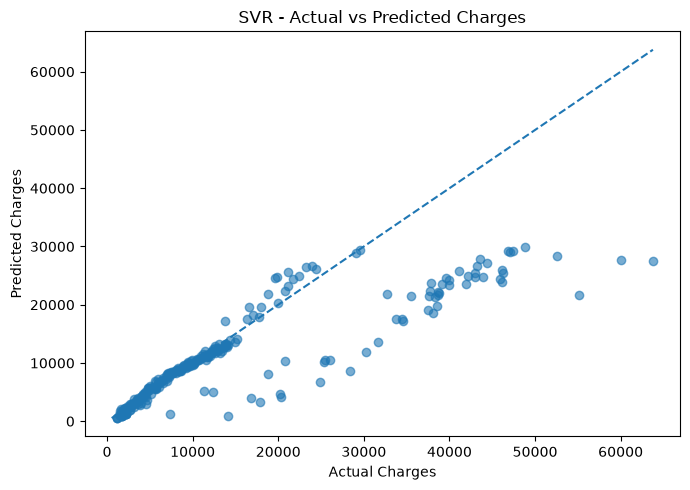

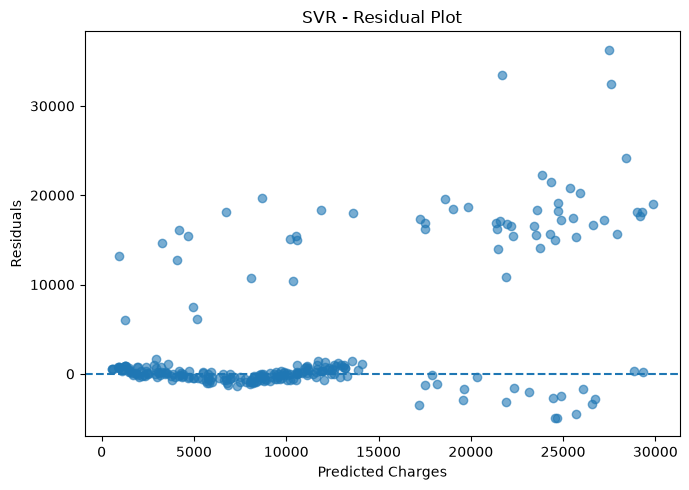

In [13]:
# Actual vs Predicted
plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.6
)


minimum_value = min(
    y_test.min(),
    tuned_predictions.min()
)

maximum_value = max(
    y_test.max(),
    tuned_predictions.max()
)


plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    "--"
)


plt.xlabel(
    "Actual Charges"
)

plt.ylabel(
    "Predicted Charges"
)

plt.title(
    "SVR - Actual vs Predicted Charges"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "svr_actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# --------------------------------------
# Residual Plot
# --------------------------------------

residuals = (
    y_test.values
    - tuned_predictions
)


plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    tuned_predictions,
    residuals,
    alpha=0.6
)


plt.axhline(
    y=0,
    linestyle="--"
)


plt.xlabel(
    "Predicted Charges"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "SVR - Residual Plot"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "svr_residual_plot.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

In [14]:
# Baseline vs tuned results
svr_results.to_csv(

    RESULT_PATH
    / "svr_results.csv",

    index=False
)


# All GridSearchCV configurations
tuning_results.to_csv(

    RESULT_PATH
    / "svr_tuning_results.csv",

    index=False
)


# Best result for group comparison
best_svr_result = pd.DataFrame([
    {
        "Model":
            "Support Vector Regression",

        "Best_Configuration":
            str(best_params),

        "MAE":
            final_svr_result["MAE"],

        "RMSE":
            final_svr_result["RMSE"],

        "R2":
            final_svr_result["R2"],

        "CV_RMSE":
            cv_rmse_scores.mean()
    }
])


best_svr_result.to_csv(

    RESULT_PATH
    / "svr_best.csv",

    index=False
)


print("SVR Model Results:")
display(svr_results)


print("\nTop 10 Tuning Results:")
display(
    tuning_results.head(10)
)


print("\nBest SVR Result:")
display(
    best_svr_result
)


print("\nResults saved successfully.")

print(
    "Saved:",
    RESULT_PATH / "svr_results.csv"
)

print(
    "Saved:",
    RESULT_PATH / "svr_tuning_results.csv"
)

print(
    "Saved:",
    RESULT_PATH / "svr_best.csv"
)

SVR Model Results:


,Model,MAE,RMSE,R2
0,SVR - Tuned,4169.139793,8338.431767,0.621621
1,SVR - Baseline,9251.152178,14424.394400,-0.132279



Top 10 Tuning Results:


,Kernel,C,Epsilon,Gamma,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,linear,1000.0,0.1,scale,7393.123593,7380.189481,613.693412
1,linear,1000.0,0.1,auto,7393.123593,7380.189481,613.693412
2,linear,1000.0,0.5,scale,7393.175921,7380.237623,613.692205
3,linear,1000.0,0.5,auto,7393.175921,7380.237623,613.692205
4,linear,1000.0,1.0,auto,7393.292287,7380.350445,613.570111
5,linear,1000.0,1.0,scale,7393.292287,7380.350445,613.570111
6,linear,100.0,1.0,auto,8238.533187,8221.704631,565.719423
7,linear,100.0,1.0,scale,8238.533187,8221.704631,565.719423
8,linear,100.0,0.5,auto,8238.688774,8221.841251,565.776584
9,linear,100.0,0.5,scale,8238.688774,8221.841251,565.776584



Best SVR Result:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,Support Vector Regression,"{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale', ...",4169.139793,8338.431767,0.621621,7380.189481



Results saved successfully.
Saved: ..\results\model_results\svr_results.csv
Saved: ..\results\model_results\svr_tuning_results.csv
Saved: ..\results\model_results\svr_best.csv


## Conclusion, Limitations and Improvements

### Conclusion
A baseline SVR model and multiple tuned SVR configurations were evaluated. GridSearchCV with five-fold cross-validation was used to test combinations of `kernel`, `C`, `epsilon`, and `gamma`.

The baseline and tuned models were compared using MAE, RMSE, and R². The tuned SVR result is saved for the final group-level comparison with the other regression models.

### Limitations
- SVR performance is sensitive to the selected hyperparameters.
- Training can become computationally expensive when the dataset or hyperparameter search space becomes large.
- SVR is less interpretable than simple linear regression models.
- SVR is sensitive to feature scale, so appropriate feature preprocessing is important.

### Possible Improvements
- Test a wider or more focused hyperparameter range.
- Investigate additional kernel functions.
- Use more advanced hyperparameter optimization methods.
- Compare the tuned SVR model with tree-based and instance-based regression models.